# Marching Qubes Vertex Classification with EHands and QCrank
## Brandon Watanabe


In [1]:
# imports, part 1
import numpy as np
import matplotlib.pyplot as plt
import math
from math import pi
import random
import sys
from dotenv import load_dotenv
import os
from pathlib import Path
from collections import defaultdict

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import Statevector, Operator, Pauli
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_distribution, array_to_latex
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.options.sampler_options import SamplerOptions

print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.3.0


In [2]:
# Adapted from Chris Pestano's QSobel
load_dotenv()
data_encoder_circuits_path = os.getenv('DATA_ENCODER_CIRCUITS_PATH')

if data_encoder_circuits_path is None:
    raise EnvironmentError("DATA_ENCODER_CIRCUITS_PATH environment variable is not set. Please set it to the path of data-encoder-circuits.")

print(f"Using DATA_ENCODER_CIRCUITS_PATH from environment variable: {data_encoder_circuits_path}")
circuits_path = data_encoder_circuits_path

# Add to sys.path if not already present
if circuits_path not in sys.path:
    sys.path.insert(0, circuits_path)

print(f"Added to sys.path: {circuits_path}")
print(f"Current working directory: {os.getcwd()}")

from datacircuits.ParametricQCrankV2 import ParametricQCrankV2 as QCrankV2, analyze_qcrank_residuals

Using DATA_ENCODER_CIRCUITS_PATH from environment variable: C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits
Added to sys.path: C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits
Current working directory: c:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis


In [3]:
sim = AerSimulator()

print(sim)
print(f"\nConfiguration: {sim.configuration()}")

if hasattr(sim, 'available_methods'):
    print(f"Available methods: {sim.available_methods()}")
else:
    print(sim.configuration())

if hasattr(sim, 'available_devices'):
    print(f"Available devices: {sim.available_devices()}")
else:
    print(sim.configuration())   

AerSimulator('aer_simulator')

Configuration: <qiskit_aer.backends.backendconfiguration.AerBackendConfiguration object at 0x000002B3C1536210>
Available methods: ('automatic', 'statevector', 'density_matrix', 'stabilizer', 'matrix_product_state', 'extended_stabilizer', 'unitary', 'superop')
Available devices: ('CPU',)


In [4]:
def run_sim_job(qc, n_shots = 2**8, verbose=False):
    """ 
    Run a quantum circuit on the simulator and return the counts.
    
    :param qc: QuantumCircuit to run
    :param n_shots: Number of shots to run the circuit for
    :param verbose: If True, print the circuit and counts

    :return: Counts of the measurement outcomes
    """

    transpiled_circuit = transpile(qc, sim)    
    job = sim.run(transpiled_circuit, shots=n_shots)
    result = job.result()
    
    # Get counts and output distribution
    counts = result.get_counts(transpiled_circuit)

    if verbose:
        print("Circuit before transpilation")
        display(qc.draw('mpl'))
        print("Circuit after transpilation")
        display(transpiled_circuit.draw('mpl', style="iqp"))

        print("Counts:")
        print(counts)
        display(plot_distribution(counts))

    return counts

In [5]:
def display_statevector(qc):
    """
    Display the statevector, unitary matrix, and Bloch sphere representation of a quantum circuit.

    :param qc: QuantumCircuit to analyze

    :return: Statevector of the quantum circuit
    """
    # Get Statevector
    state = Statevector.from_instruction(qc)

    # Display Statevector
    print("\nStatevector:")
    display(state.draw("latex"))

    matrix_form = np.array(state).reshape(-1, 1)
    print("\nStatevector as a matrix:")
    display(array_to_latex(matrix_form))
    
    # Display the Unitary Matrix
    print("Unitary matrix:")
    display(Operator(qc).draw("latex"))

    # Display Bloch Sphere
    display(plot_bloch_multivector(state))

    return state

In [6]:
def plot_residuals(actual, theory, title, x_label, y_label, legend):
    min_val = min(min(actual), min(theory))
    max_val = max(max(actual), max(theory))

    plt.scatter(theory, actual, label=legend)
    # calculate slope of line of best fit
    coefficients = np.polyfit(theory, actual, 1)
    print(f"Slope of line of best fit: {coefficients[0]:.4f}")
    # plot line of best fit
    plt.plot(theory, np.poly1d(coefficients)(theory), color='red', label='Line of Best Fit')    

    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()

    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.gca().set_aspect('equal', adjustable='box')

    plt.grid(True)

    plt.show()

In [7]:
def ehands_addition(qc, q_a, q_b, weight, negation=False, verbose=False):
    """ 
    Perform an EHands addition of two qubits with a given weight and optional negation.

    :param qc: QuantumCircuit to which the addition will be applied
    :param q_a: Index of the first qubit
    :param q_b: Index of the second qubit
    :param weight: Weight for the addition (between 0 and 1)
    :param negation: If True, negate the second qubit before addition

    :return: QuantumCircuit with the eHANDS addition applied   
    """
    alpha = np.arccos(1 - 2 * weight)

    qc_add = QuantumCircuit(2)

    if negation:
        qc_add.x(1)

    qc_add.rz(pi/2, 1)
    qc_add.cx(0, 1)
    qc_add.ry(alpha/2, 0)
    qc_add.cx(1, 0) 
    qc_add.ry(-alpha/2, 0)

    if verbose:
        print("Addition Circuit:")
        display(qc_add.draw('mpl'))
    
    return qc.compose(qc_add, qubits=[q_a, q_b])


## Vertex Classification Setup with QCrank

In [92]:
def configure_qcrank_options(n_shots):
    options = SamplerOptions()
    options.default_shots=n_shots
    return options

In [93]:
def run_sim_job_qcrank(encoding_args, n_shots = 2**12, verbose=False):
    """ 
    Run a quantum circuit on the simulator and return the counts.
    
    :param encoding_args: dictionary including information about the QC of encoded data
    :param n_shots: number of shots to run
    :param verbose: print out extra details and draw circuit

    :return: Counts of the measurement outcomes
    """
    options = configure_qcrank_options(n_shots)
    sampler = Sampler(mode=sim, options=options)

    job = sampler.run(tuple(encoding_args['qcEL']))
    jobRes = job.result()

    #countsL = [jobRes[0].data.meas.get_counts()]
    countsL = [jobRes[0].data.c.get_counts()]

    if verbose:
        qc = encoding_args['qc']
        cxDepth=qc.depth(filter_function=lambda x: x.operation.name == 'cx')
        print(f'.... PARAMETRIZED CIRCUIT .............., cx-depth={cxDepth}')
        print('Gates count:', qc.count_ops())
        display(qc.draw('mpl'))


    return countsL

In [100]:
def initialize_n_data(n_cubes, data_range, make_iso_array=False, isovalue=0.5):
    n_data = 2**3 # data per array
    nq_addr = math.ceil(math.log2(n_data))
    nq_data = n_cubes

    if make_iso_array:
        n_arr -= 1
        
    data_inp = np.random.uniform(data_range[0], data_range[1], size=(n_data, nq_data, n_cubes))
    print(data_inp)

    if make_iso_array:
        data_inp.append(np.full((n_data, 1), isovalue))

    return {
        'n_data': n_data,
        'nq_addr': nq_addr,
        'nq_data': nq_data,
        'num_q': nq_addr + nq_data,
        'addr_qL': list(range(nq_addr)),
        'data_qL': list(range(nq_addr, nq_addr + nq_data)),
        'data_inp': data_inp
    }

In [95]:
def encode_with_qcrank_2(data_args, useCZ=False, measure=True, barrier=True):
    nq_addr = data_args['nq_addr']
    nq_data = data_args['nq_data']

    qcrankObj = QCrankV2(nq_addr, nq_data, useCZ=useCZ, measure=measure, barrier=barrier)

    qc = qcrankObj.circuit
    
    qcrankObj.bind_data(data_args['data_inp'])

    qcEL = qcrankObj.instantiate_circuits()
    return {
        'qc': qc,
        'qcEL': qcEL,
        'nq_addr': nq_addr,
        'nq_data': nq_data,
        'qcrankObj': qcrankObj
    }

In [96]:
def analyze_all_qcrank_residuals(data_args, recoveredL, all_data_list, all_rec_list, verbose=False):
    # Iterate over all input arrays
    for i in range(data_args['nq_data']):
        # Save data and recovered to lists
        all_data_list[i].append(data_args['data_inp'][i, :, :])
        all_rec_list[i].append(recoveredL[i])

        # QCrank analysis
        print(f"Analyzing residuals for array {i}")
        analyze_qcrank_residuals(data_args['data_inp'][i, :, :], recoveredL[i])
        
        if verbose:
            print(f'\nCube original data:\n', data_args['data_inp'][i, :, :].T)
            print(f'Reconstructed data:\n', recoveredL[i].T)
            print(f'Difference:\n', (data_args['data_inp'][i, :, :] - recoveredL[i]).T)
            if i > 2: 
                break

In [97]:
def add_iso_qubit_for_ehands(qc, data_q, placement_q, isovalue, weight, negation=True, verbose=False):
    qc_iso = QuantumCircuit(1, 1)
    qc_iso.ry(np.arccos(isovalue), 0)

    qc.compose(qc_iso, placement_q, inplace=True)

    qc.barrier()
    qc = ehands_addition(qc, data_q, placement_q, weight=weight, verbose=verbose)
    qc.barrier()

    return qc


## Method 2
### Encode Data array using QCrank, encode Isovalue using single Ry gate

Chose method 2 because it produces the same result as method 1 with far fewer gates

In [102]:
def test_qcrank_ehands_single_iso_n_data(n_cubes):
    isovalue = 0.5
    weight = 0.5
    verbose = True

    all_data_list = [[] for _ in range(n_cubes)]
    all_rec_list = [[] for _ in range(n_cubes)]
    
    for _ in range(20):
        # initialize data and isovalue arrays
        data_args = initialize_n_data(n_cubes, (-0.99, 0.99), make_iso_array=False)

        qc_main = QuantumCircuit(data_args['num_q'] + n_cubes, data_args['num_q'] + n_cubes)

        # encode sample data into qcrank
        qcrank_encoding_args = encode_with_qcrank_2(data_args, measure=False)

        qc_main.compose(qcrank_encoding_args['qcEL'][0], list(range(data_args['num_q'])), inplace=True)

        print(f"data_qL: {data_args['data_qL']}")

        # add iso value qubit 
        for i in range(n_cubes):
            q_a = data_args['data_qL'][i]
            q_b = data_args['num_q'] + i 
            print(f"q_a: {q_a}, q_b: {q_b}, for i: {i}")
            qc_main = add_iso_qubit_for_ehands(qc_main, q_a, q_b, isovalue, weight, verbose=verbose)

        # Add measurement
        qc_main.barrier()
        qc_main.measure(list(range(data_args['num_q'])), reversed(list(range(data_args['num_q']))))

        qcrank_encoding_args['qc'] = qc_main
        qcrank_encoding_args['qcEL'] = [qc_main]

        # Run Simulation
        n_shots = data_args['n_data'] * (2**12)
        countsL = run_sim_job_qcrank(qcrank_encoding_args, n_shots, verbose)

        # Recover the data from QC
        qcrankObj = qcrank_encoding_args['qcrankObj']
        data_rec, data_recErr = qcrankObj.reco_from_yields(countsL)

        recoveredL = []
        recoveredErrL = []
        for i in range(data_args['nq_data']):
            recoveredL.append(data_rec[:, i, :].reshape(data_args['n_data'], 1))
            recoveredErrL.append(data_recErr[:, i, :].reshape(data_args['n_data'], 1))

        shpad = n_shots / 2**data_args['nq_addr']
        print(f'Shots per address: {shpad:.1f}, relative error ~ {1/np.sqrt(shpad):.3f}')

        analyze_all_qcrank_residuals(data_args, recoveredL, all_data_list, all_rec_list, verbose=verbose)
        
        # verbose for first iteration to draw circuit
        verbose = False
        
    print("Returning data and recovered data lists")
    return all_rec_list, all_data_list
    

[[[-0.71385516 -0.96320697 -0.59794396 -0.73509996]
  [ 0.12859026 -0.92964427  0.49328827  0.68475012]
  [-0.58556838 -0.70354258 -0.7478408  -0.63762042]
  [ 0.86093605  0.88708813  0.83289583  0.44997825]]

 [[-0.19737665 -0.04291923  0.59847181  0.41510096]
  [ 0.09772713 -0.89375596 -0.40381623 -0.86443913]
  [-0.67531751 -0.8921619   0.5074771   0.34650222]
  [-0.42842475 -0.6391564   0.4523777   0.62001   ]]

 [[-0.37366282  0.50230284 -0.91933237 -0.62852319]
  [-0.42513066 -0.34337917 -0.58431038  0.04070145]
  [-0.15463965 -0.61808545 -0.78421327 -0.97130028]
  [-0.25916118  0.35235153 -0.4693651  -0.32627572]]

 [[ 0.15571483 -0.32141122  0.94025764  0.97239763]
  [-0.22125061 -0.88931028  0.50685306  0.54991448]
  [ 0.08002634 -0.17405064  0.35966071  0.40725018]
  [ 0.35473145  0.43069784  0.37442115 -0.84265811]]

 [[-0.69745249  0.10754276  0.47784126  0.46188689]
  [ 0.33182113 -0.32970603 -0.86440433  0.78506313]
  [ 0.69475103  0.14763579 -0.29261512 -0.93132931]
  [-

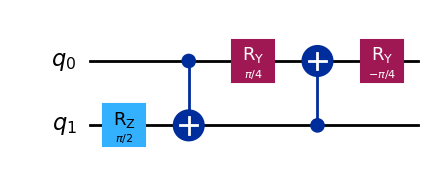

q_a: 4, q_b: 8, for i: 1
Addition Circuit:


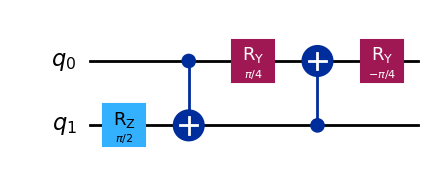

q_a: 5, q_b: 9, for i: 2
Addition Circuit:


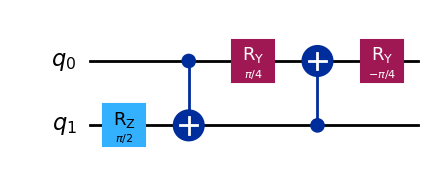

q_a: 6, q_b: 10, for i: 3
Addition Circuit:


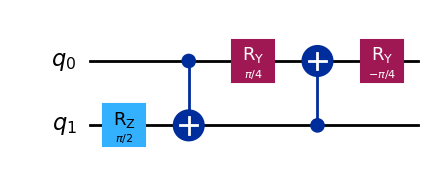

.... PARAMETRIZED CIRCUIT .............., cx-depth=20
Gates count: OrderedDict({'ry': 44, 'cx': 40, 'barrier': 10, 'measure': 7, 'rz': 4, 'h': 3})


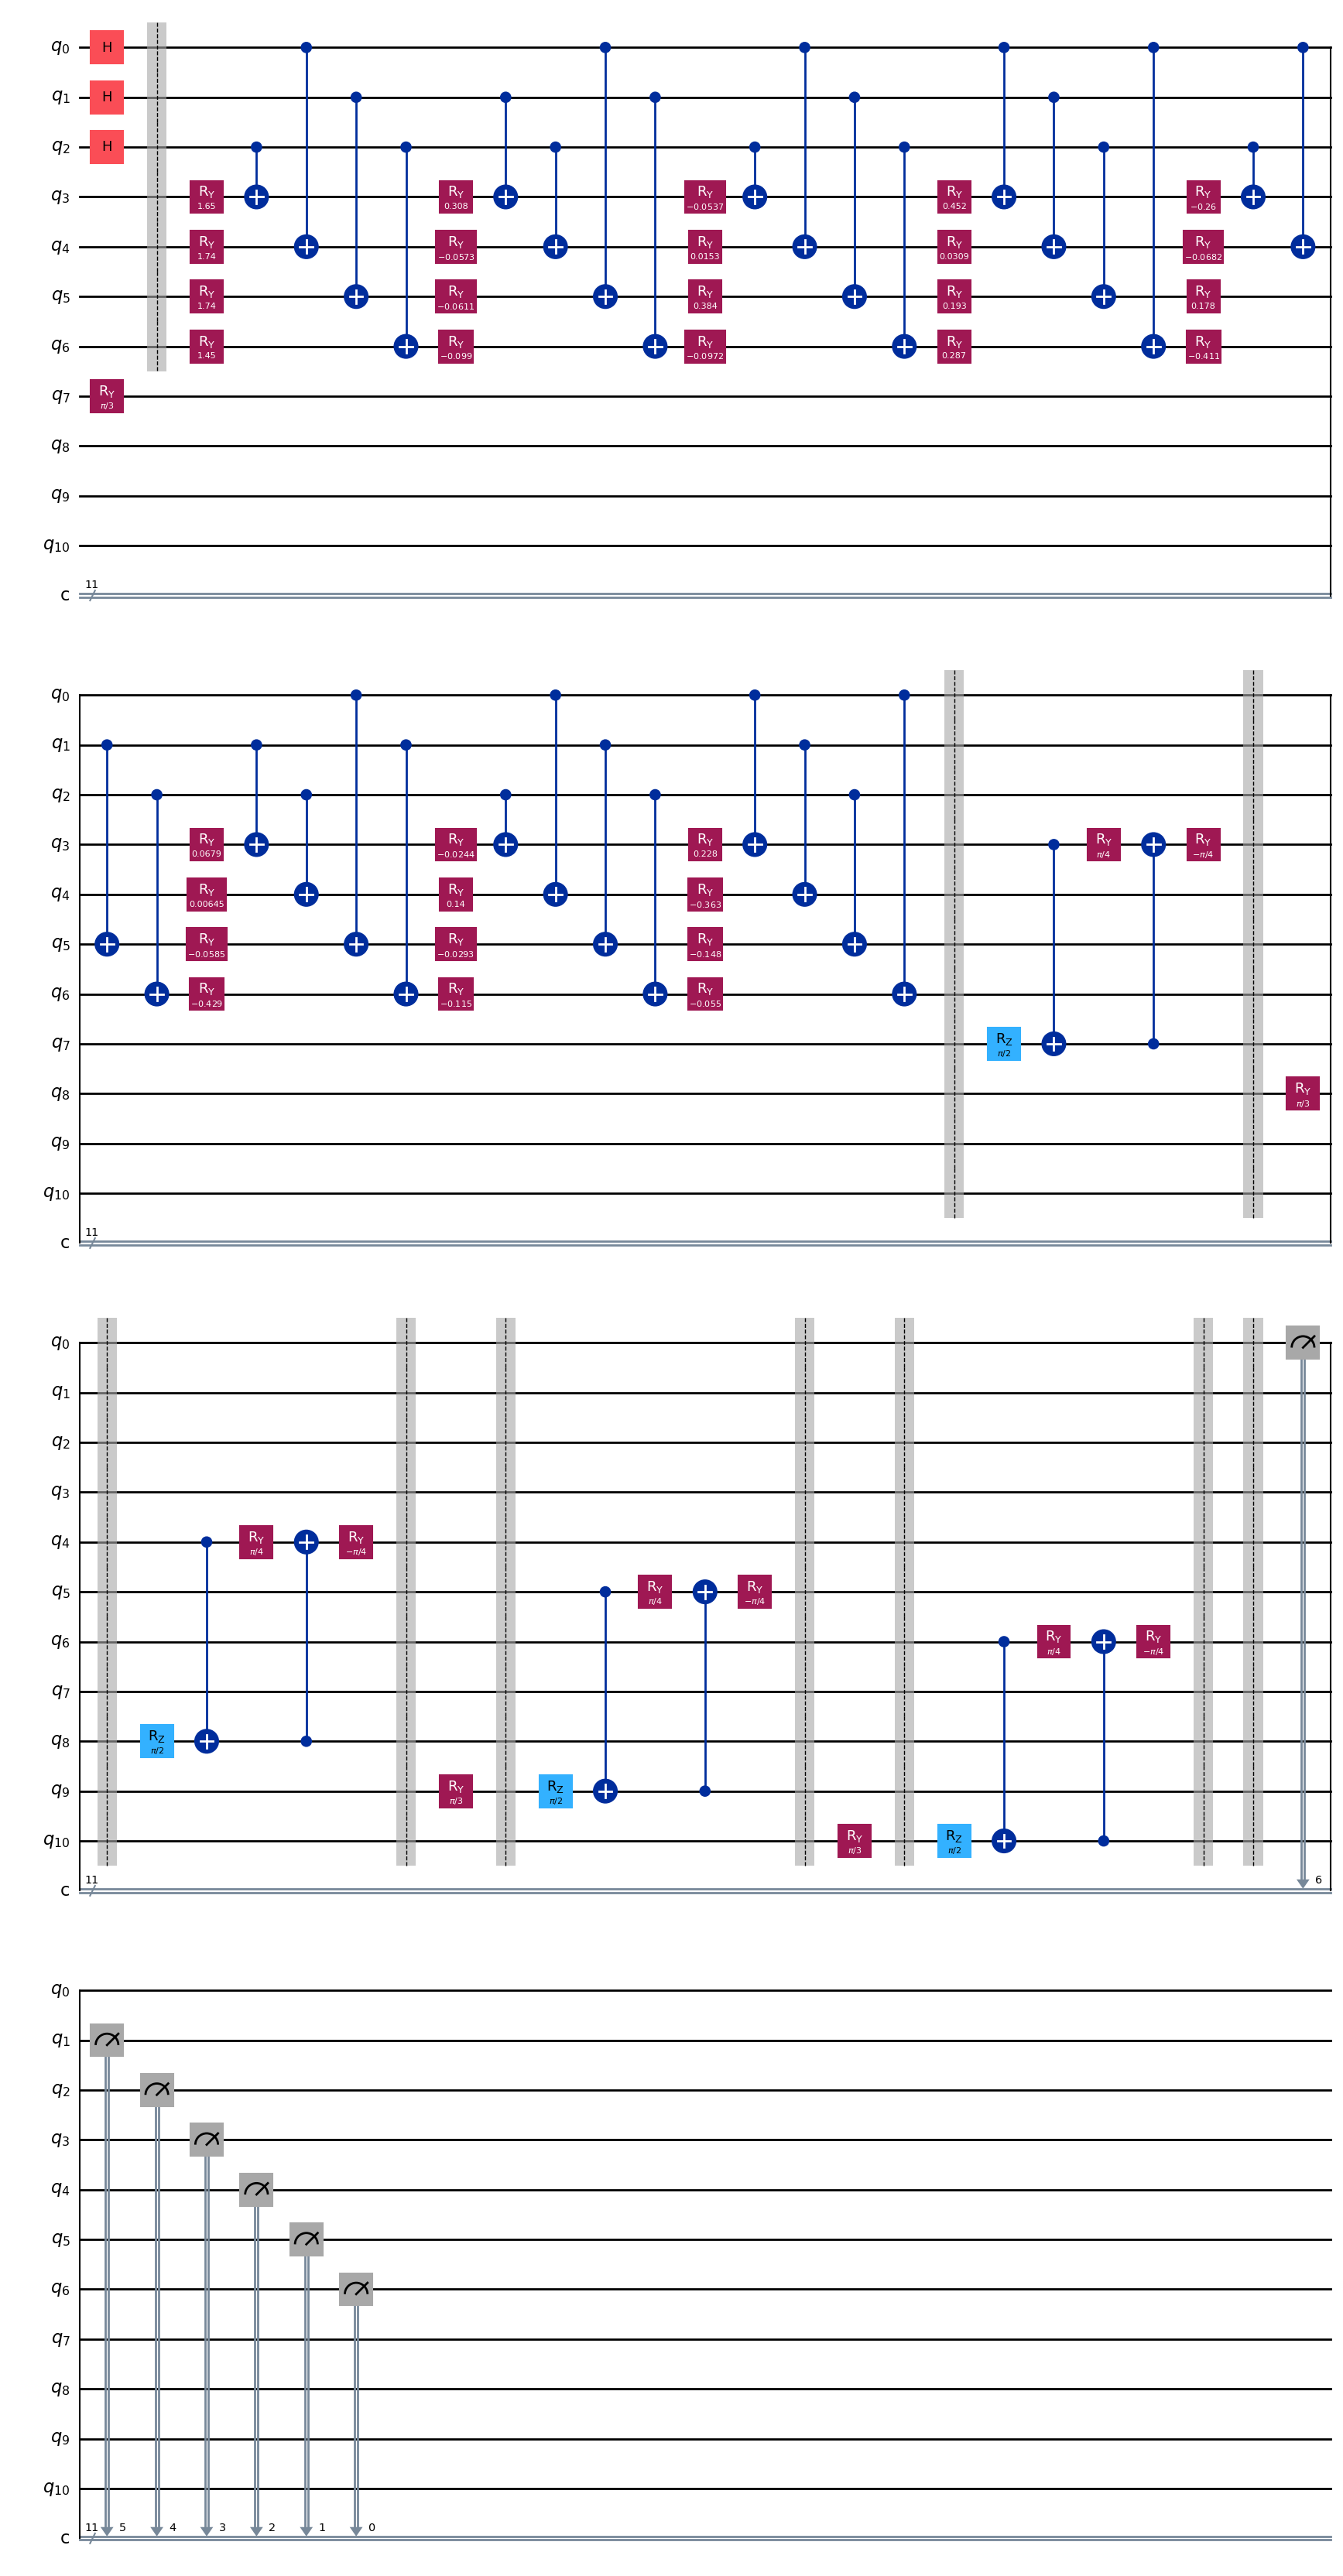

QRFY: nq_addr,nq_data= 3 4  addrBitsL: [4, 5, 6]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 4 imges


ValueError: operands could not be broadcast together with shapes (4,) (8,) 

In [103]:
n_cubes = 4
all_rec_list, all_data_list = test_qcrank_ehands_single_iso_n_data(n_cubes)

-----------------------------Analysis of Original vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Data  | Reconstructed  | Difference     |
+----------------+----------------+----------------+
| -0.592494      | -0.077821      | -0.514673      |
| 0.364095       | 0.457255       | -0.093159      |
| -0.222317      | 0.150074       | -0.372391      |
| -0.969791      | -0.227959      | -0.741832      |
| -0.058763      | 0.231539       | -0.290303      |
| -0.277533      | 0.108877       | -0.386410      |
| -0.631733      | -0.068314      | -0.563419      |
| -0.021341      | 0.214608       | -0.235949      |
| 0.512060       | 0.516446       | -0.004386      |
| -0.518563      | 0.007496       | -0.526059      |
| 0.154798       | 0.335468       | -0.180670      |
| 0.762420       | 0.631667       | 0.130753       |
| -0.044574      | 0.222168       | -0.266742      |
| -0.161625      | 0.166294       | -0.327919      

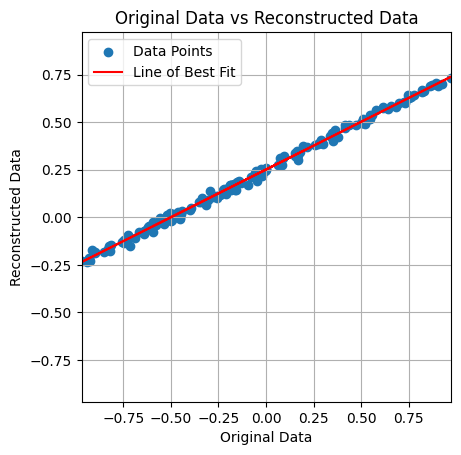

-----------------------------Analysis of Original vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Data  | Reconstructed  | Difference     |
+----------------+----------------+----------------+
| -0.042895      | 0.259241       | -0.302136      |
| 0.747840       | 0.607719       | 0.140121       |
| -0.235395      | 0.133234       | -0.368629      |
| 0.782136       | 0.635655       | 0.146481       |
| 0.170676       | 0.347685       | -0.177008      |
| 0.961857       | 0.721923       | 0.239934       |
| -0.855432      | -0.174903      | -0.680529      |
| 0.635345       | 0.568414       | 0.066932       |
| -0.398605      | 0.069219       | -0.467825      |
| 0.927526       | 0.720140       | 0.207386       |
| -0.427813      | 0.037438       | -0.465251      |
| 0.715323       | 0.614925       | 0.100398       |
| 0.469081       | 0.482422       | -0.013341      |
| -0.184466      | 0.165797       | -0.350262      

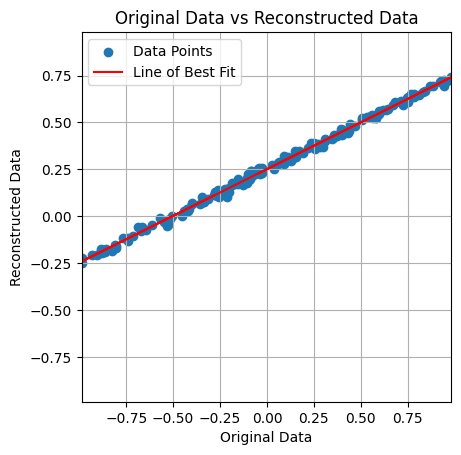

-----------------------------Analysis of Original vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Data  | Reconstructed  | Difference     |
+----------------+----------------+----------------+


IndexError: list index out of range

In [55]:
for i in range(n_cubes):
    print("-----------------------------Analysis of Original vs Reconstructed----------------------------------")
    avg_dif = 0
    print("+----------------+----------------+----------------+")
    print("| Original Data  | Reconstructed  | Difference     |")
    print("+----------------+----------------+----------------+")

    for o, r in zip(np.concatenate(all_data_list[i]).flatten(),
                    np.concatenate(all_rec_list[i]).flatten()):
        dif = o - r
        avg_dif += dif
        print(f"| {o:<14.6f} | {r:<14.6f} | {dif:<14.6f} |")

    print("+----------------+----------------+----------------+")

    n_points = len(np.concatenate(all_data_list[i]).flatten())
    avg_dif /= n_points

    print(f"Average Difference: {avg_dif}")


    title = 'Original Data vs Reconstructed Data'
    x_label = 'Original Data'
    y_label = 'Reconstructed Data'
    legend = 'Data Points'
    plot_residuals(np.concatenate(all_rec_list[i]).flatten(),
                    np.concatenate(all_data_list[i]).flatten(), 
                    title, x_label, y_label, legend)